In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from liu_inertia_estimation import *
from generate_noise import * 
from calculate_metrics import calculate_inertia_rmse, convergence_time

In [5]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
out_dir = project_dir / "out/3_E2_test"
noise_out_path = project_dir / "out/2_noise/sweep_metrics.csv"
sim_out = project_dir / "out/simulation_data/simulation_timeseries.csv"

## Run Monte Carlo for E2 ONLY

In [3]:
simulation_timeseries = pd.read_csv(sim_out)
H_TRUE = 5
TIME_STEP = 0.001

t_est = simulation_timeseries.time
omega = simulation_timeseries["omega_int"]
power = simulation_timeseries["Pe_pu"]

In [8]:
mc = pd.read_csv(noise_out_path)
_e2 = mc[mc.est == 'E2']

In [ ]:
TAU_OPT = float(_e2.loc[_e2.rmse.idxmin()].tau_ms * 1e-3) # find tau with best rmse
N_SEEDS_READ = 200
T_GRID = np.arange(0.10, 4.0001, 0.02)          
CONF = [50, 90, 99]

print(f'E2,  tau = {TAU_OPT*1e3:.0f} ms')
print(f'{N_SEEDS_READ} noise realisations, {len(T_GRID)} read times '
      f'({(T_GRID[1]-T_GRID[0])*1e3:.0f} ms apart)')

# rerun monte carlo kind of (with just E2 & fixed tau at optimal value)
read_traj = [run_all_estimators(omega, power, t_est, TAU_OPT, noise=ou_noise(len(t_est), seed=s))['E2']
             for s in range(N_SEEDS_READ)]

# error of the running median 
err = np.empty((len(T_GRID), N_SEEDS_READ))
for i, T in enumerate(T_GRID):
    m_ = t_est <= T
    for j, v in enumerate(read_traj):
        vv = v[m_]
        vv = vv[np.isfinite(vv)]
        err[i, j] = 100 * (np.median(vv) - H_TRUE) / H_TRUE

abs_err = np.abs(err)
raw = {c: np.percentile(abs_err, c, axis=1) for c in CONF}
# monotone envelope 
guar = {c: np.maximum.accumulate(raw[c][::-1])[::-1] for c in CONF}
print('computed')

E2,  tau = 54 ms
200 noise realisations, 196 read times (20 ms apart)
computed


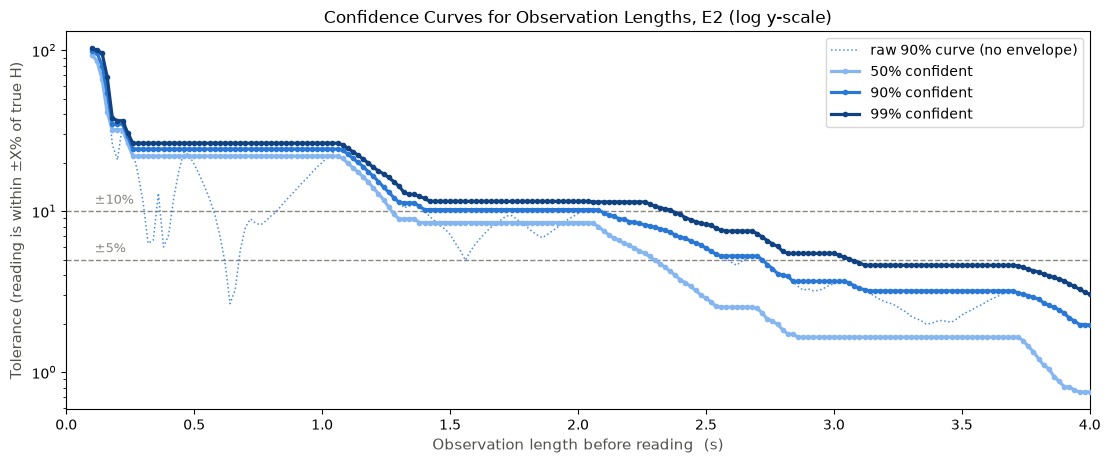

In [ ]:
# could not get the motivation to write the code to plot this freaking thing myself :(

C_CONF = ['#86b6ef', '#2a78d6', '#104281']       # validated ordinal ramp

SURFACE, PLANE = '#fcfcfb', '#f9f9f7'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID_C, AXIS = '#e1e0d9', '#c3c2b7'
C_INT, C_GRID = '#2a78d6', '#eb6834'      # validated categorical slots 1-2

C_CONF = ['#86b6ef', '#2a78d6', '#104281']       # validated ordinal ramp

fig, hx = plt.subplots(figsize=(11.5, 5.6))
fig.subplots_adjust(top=0.795, bottom=0.12, left=0.085, right=0.975)

#_style(hx, window_band=False)
for _patch in hx.patches[:]:
    _patch.remove()

# the raw (un-enveloped) curve, to show the oscillation the envelope hides
hx.plot(T_GRID, raw[90], color=C_CONF[1], lw=1.1, ls=':', alpha=0.85, zorder=3, label="raw 90% curve (no envelope)")

for _c, conf in zip(C_CONF, CONF):
    hx.plot(T_GRID, guar[conf], color=_c, lw=2.3, zorder=4, label=f'{conf}% confident', marker="o", markersize=3)

for _thr in (10, 5):
    hx.axhline(_thr, color=MUTED, lw=1.0, ls='--', zorder=2)
    hx.annotate(f'±{_thr}%', (0.10, _thr), color=MUTED, fontsize=9.5,
                ha='left', va='bottom', xytext=(2, 3),
                textcoords='offset points')

hx.set_yscale('log')
hx.set_xlim(0, 4.0)

hx.set_xlabel('Observation length before reading  (s)', color=INK2,
              fontsize=10.5)
hx.set_ylabel('Tolerance (reading is within $\\pm$X% of true H)', color=INK2,
              fontsize=10.5)

hx.set_title("Confidence Curves for Observation Lengths, E2 (log y-scale)")
hx.legend()
plt.show()